In [87]:
#
# This is a sample Notebook to demonstrate how to read "MNIST Dataset"
#
import numpy as np # linear algebra
import struct
from array import array
from os.path  import join

from numpy.ma.core import size, shape


#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())

        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img

        return images, labels

    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)



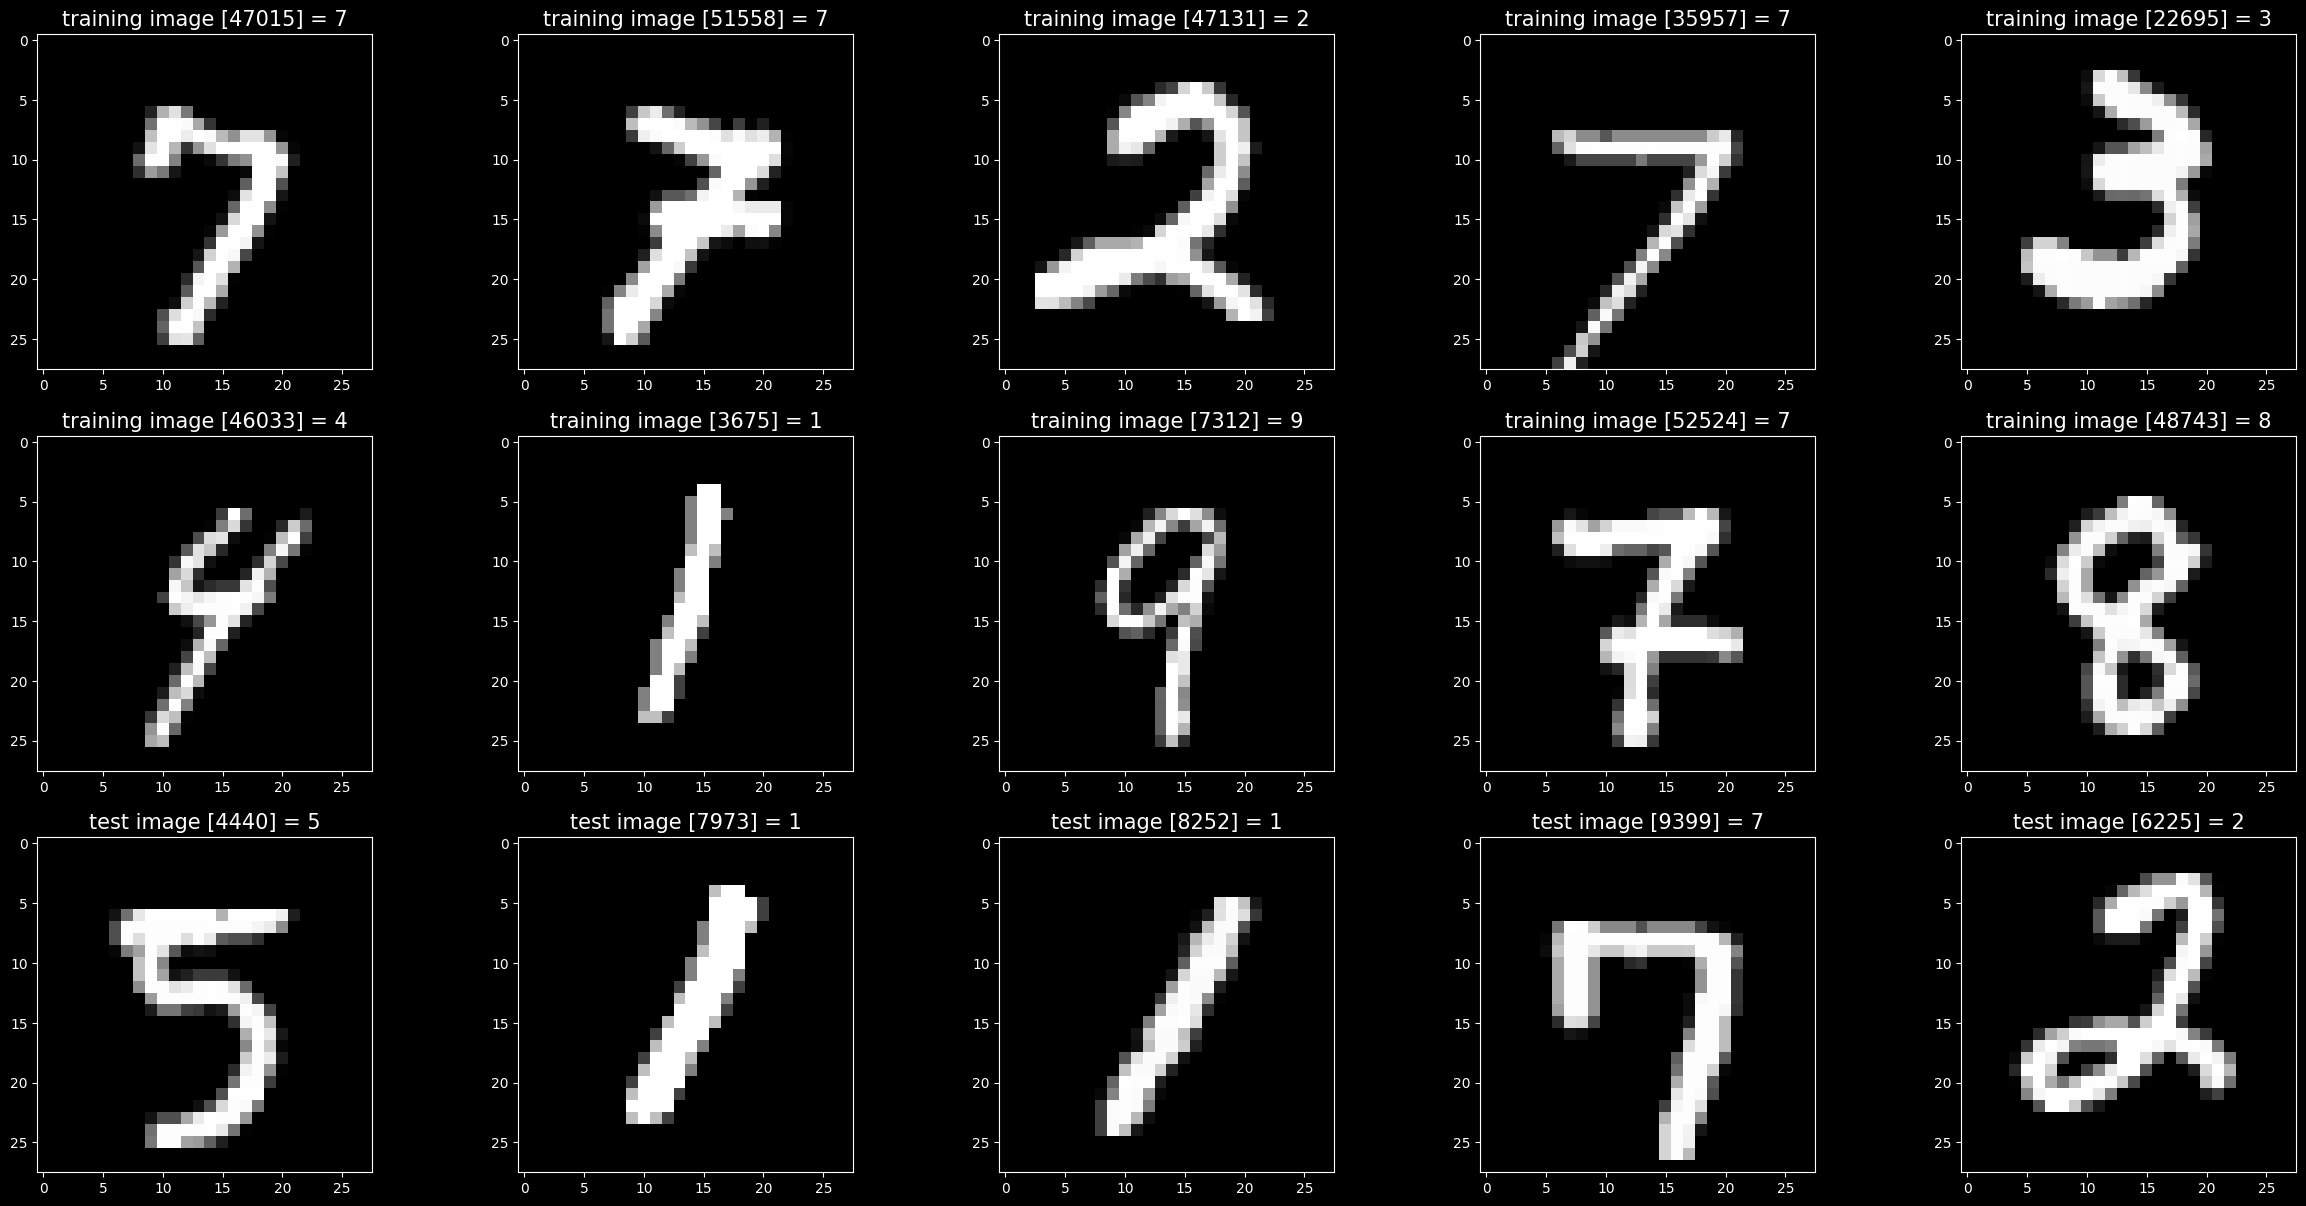

In [88]:
#
# Verify Reading Dataset via MnistDataloader class
#
%matplotlib inline
import random
import matplotlib.pyplot as plt

#
# Set file paths based on added MNIST Datasets
#
input_path = 'archive/'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1
    for x in zip(images, title_texts):
        image = x[0]
        title_text = x[1]
        plt.subplot(rows, cols, index)
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))

show_images(images_2_show, titles_2_show)


# ── 1. Preprocessing (identical to v1) ────────────────────────────────────
x_train = np.array(x_train).reshape(-1, 784) / 255.0
x_test  = np.array(x_test).reshape(-1, 784)  / 255.0
y_train = np.array(y_train)
y_test  = np.array(y_test)

In [89]:
print(np.array(x_train).shape)
print(np.array(y_train).shape)
print(np.array(x_test).shape)
print(np.array(y_test).shape)


(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [90]:
class Activation:
    """
    Bundles an activation function, its derivative, and its weight
    initialiser together.

    Two ways to create an instance
    --------------------------------
    1. By name — recommended, picks up a built-in:
           act = Activation("relu")
           act = Activation("sigmoid")
           act = Activation("tanh")
           act = Activation("softmax")   ← new

    2. Custom — supply your own functions:
           act = Activation(fn=my_fn, fn_prime=my_fn_prime,
                            init_fn=my_init, name="custom")
           If init_fn is omitted, defaults to Xavier.

    Names are case-insensitive: "ReLU", "relu", "RELU" all work.

    Note on Softmax
    ---------------
    Softmax is special: its derivative is a Jacobian matrix, not a
    simple element-wise operation. However, when paired with
    cross-entropy loss, the combined gradient simplifies beautifully
    to just (y_pred - y_true). Network handles this cancellation
    directly and never calls softmax.fn_prime during backprop.
    We still store a placeholder fn_prime so the object is uniform.
    """

    # ------------------------------------------------------------------ #
    # Built-in activation functions (private static methods)              #
    # ------------------------------------------------------------------ #

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        return 1.0 / (1.0 + np.exp(-z))

    @staticmethod
    def _sigmoid_prime(z: np.ndarray) -> np.ndarray:
        s = Activation._sigmoid(z)
        return s * (1.0 - s)

    @staticmethod
    def _relu(z: np.ndarray) -> np.ndarray:
        return np.maximum(0.0, z)

    @staticmethod
    def _relu_prime(z: np.ndarray) -> np.ndarray:
        return (z > 0).astype(float)

    @staticmethod
    def _tanh(z: np.ndarray) -> np.ndarray:
        return np.tanh(z)

    @staticmethod
    def _tanh_prime(z: np.ndarray) -> np.ndarray:
        return 1.0 - np.tanh(z) ** 2

    @staticmethod
    def _softmax(z: np.ndarray) -> np.ndarray:
        # Subtract max for numerical stability — prevents e^z overflow.
        # Subtracting a constant from every element doesn't change the
        # output because it cancels in the numerator and denominator.
        # Works for both single sample (1D) and batch (2D).
        z_stable = z - np.max(z, axis=-1, keepdims=True)
        e = np.exp(z_stable)
        return e / np.sum(e, axis=-1, keepdims=True)

    @staticmethod
    def _softmax_prime(z: np.ndarray) -> np.ndarray:
        # Placeholder — never called when loss="cross_entropy".
        # Network short-circuits the gradient to (y_pred - y_true) / N
        # which is the combined Softmax + CrossEntropy gradient.
        raise NotImplementedError(
            "Softmax derivative is not used directly. "
            "Use loss='cross_entropy' in Network, which applies the "
            "combined Softmax+CrossEntropy gradient automatically."
        )

    # ------------------------------------------------------------------ #
    # Built-in weight initialisers (private static methods)               #
    # ------------------------------------------------------------------ #

    @staticmethod
    def _xavier_init(n_out: int, n_in: int) -> np.ndarray:
        std = np.sqrt(1.0 / n_in)
        return np.random.randn(n_out, n_in) * std

    @staticmethod
    def _he_init(n_out: int, n_in: int) -> np.ndarray:
        std = np.sqrt(2.0 / n_in)
        return np.random.randn(n_out, n_in) * std

    # ------------------------------------------------------------------ #
    # Registry — maps lowercase name → (fn, fn_prime, init_fn)           #
    # Adding a new built-in = one new entry here. Nothing else changes.  #
    # ------------------------------------------------------------------ #

    _REGISTRY = {
        "sigmoid": (_sigmoid.__func__, _sigmoid_prime.__func__, _xavier_init.__func__),
        "relu":    (_relu.__func__,    _relu_prime.__func__,    _he_init.__func__),
        "tanh":    (_tanh.__func__,    _tanh_prime.__func__,    _xavier_init.__func__),
        "softmax": (_softmax.__func__, _softmax_prime.__func__, _xavier_init.__func__),
    }

    # ------------------------------------------------------------------ #
    # Constructor                                                          #
    # ------------------------------------------------------------------ #

    def __init__(self, name: str = None, fn=None, fn_prime=None, init_fn=None):
        if fn is not None and fn_prime is not None:
            self.fn       = fn
            self.fn_prime = fn_prime
            self.init_fn  = init_fn if init_fn is not None else self._xavier_init
            self.name     = name or "custom"
        elif name is not None:
            key = name.lower()
            if key not in self._REGISTRY:
                available = ", ".join(self._REGISTRY.keys())
                raise ValueError(
                    f"Unknown activation '{name}'. "
                    f"Available built-ins: {available}. "
                    f"For a custom activation, pass fn and fn_prime."
                )
            self.fn, self.fn_prime, self.init_fn = self._REGISTRY[key]
            self.name = key.capitalize()
        else:
            raise ValueError(
                "Provide a built-in name (e.g. Activation('relu')) "
                "or custom functions (Activation(fn=..., fn_prime=..., name=...))."
            )

    def __repr__(self) -> str:
        return f"Activation({self.name})"


In [91]:

class Layer:
    """
    A fully-connected (dense) layer.

    Do not instantiate directly. Use the class methods:
        Layer.Dense(n_out, activation=Activation("relu"))

    This keeps the door open for future layer types (Conv, Dropout, etc.)
    without breaking the existing API.
    """

    def __init__(self, n_in: int, n_out: int, activation: Activation):
        """
        Internal constructor. Called by Layer.Dense() after n_in is
        resolved by Network from the previous layer's n_out.
        """
        self.activation = activation
        self.W  = self.activation.init_fn(n_out, n_in)  # (n_out, n_in)
        self.b  = np.zeros(n_out)                        # (n_out,)
        self._a_in = None
        self._z    = None
        self.dW    = None
        self.db    = None

    # ------------------------------------------------------------------ #
    # Public factory — the only way to create a layer from user code      #
    # ------------------------------------------------------------------ #

    @classmethod
    def Dense(cls, n_out: int, activation: Activation = None) -> "_DenseSpec":
        """
        Declare a dense layer with n_out neurons and an activation.

        n_in is NOT required here — Network infers it automatically
        from the previous layer (or from input_size for the first layer).

        Returns a _DenseSpec, a lightweight spec object that Network
        uses to build the real Layer once it knows n_in.

        Example
        -------
            Layer.Dense(16, activation=Activation("relu"))
            Layer.Dense(10, activation=Activation("softmax"))
        """
        act = activation if activation is not None else Activation("sigmoid")
        return _DenseSpec(n_out=n_out, activation=act)

    # ------------------------------------------------------------------ #
    # Forward pass                                                         #
    # ------------------------------------------------------------------ #

    def forward(self, a_in: np.ndarray) -> np.ndarray:
        self._a_in = a_in
        self._z    = a_in @ self.W.T + self.b
        return self.activation.fn(self._z)

    # ------------------------------------------------------------------ #
    # Backward pass                                                        #
    # ------------------------------------------------------------------ #

    def backward(self, delta_in: np.ndarray) -> np.ndarray:
        """
        General backward pass used for all hidden layers.

        For the output layer with cross-entropy + softmax, Network
        bypasses this and injects the combined gradient directly,
        so fn_prime is never called on a Softmax layer.
        """
        delta = delta_in * self.activation.fn_prime(self._z)

        if delta.ndim == 1:         # 1 sample
            self.dW = np.outer(delta, self._a_in)
        else:                       # a batch of samples
            self.dW = (delta.T @ self._a_in) / delta.shape[0]

        self.db = delta.mean(axis=0) if delta.ndim > 1 else delta
        return delta @ self.W

    def backward_output_crossentropy(self, delta_in: np.ndarray) -> np.ndarray:
        """
        Specialised backward for the output layer when using cross-entropy.

        The combined Softmax+CrossEntropy gradient is:
            ∂(CE)/∂z = y_pred - y_true   (already divided by N)

        This is passed in directly as delta_in — no fn_prime needed.
        We skip straight to computing dW and db and passing delta back.
        """
        delta = delta_in   # already the correct gradient, no fn_prime step

        if delta.ndim == 1:
            self.dW = np.outer(delta, self._a_in)
        else:
            self.dW = (delta.T @ self._a_in) / delta.shape[0]

        self.db = delta.mean(axis=0) if delta.ndim > 1 else delta
        return delta @ self.W

    # ------------------------------------------------------------------ #
    # Parameter update                                                   #
    # ------------------------------------------------------------------ #

    def update(self, lr: float) -> None:
        self.W -= lr * self.dW
        self.b -= lr * self.db

    # ------------------------------------------------------------------ #
    # Utility                                                              #
    # ------------------------------------------------------------------ #

    def __repr__(self) -> str:
        return (f"Layer(n_in={self.W.shape[1]}, n_out={self.W.shape[0]}, "
                f"activation={self.activation.name}, "
                f"params={self.W.size + self.b.size})")


class _DenseSpec:
    """
    Lightweight specification object returned by Layer.Dense().

    Holds n_out and activation but NOT n_in — that is filled in by
    Network once it knows the output size of the previous layer.
    Users never interact with this directly.
    """
    def __init__(self, n_out: int, activation: Activation):
        self.n_out      = n_out
        self.activation = activation

    def build(self, n_in: int) -> Layer:
        """Materialise into a real Layer once n_in is known."""
        return Layer(n_in=n_in, n_out=self.n_out, activation=self.activation)

    def __repr__(self) -> str:
        return f"DenseSpec(n_out={self.n_out}, activation={self.activation.name})"


In [92]:
import numpy as np



class Network:
    """
    A fully-connected feedforward neural network.

    Usage — MSE + Sigmoid (default)
    --------------------------------
        net = Network(
            input_size=784,
            layers=[
                Layer.Dense(16, activation=Activation("sigmoid")),
                Layer.Dense(16, activation=Activation("sigmoid")),
                Layer.Dense(10, activation=Activation("sigmoid")),
            ]
        )

    Usage — Cross-Entropy + Softmax
    --------------------------------
        net = Network(
            input_size=784,
            layers=[
                Layer.Dense(16, activation=Activation("relu")),
                Layer.Dense(16, activation=Activation("relu")),
                Layer.Dense(10, activation=Activation("softmax")),
            ],
            loss="cross_entropy"
        )

    Supported loss values
    ---------------------
        "mse"            — Mean Squared Error  (default)
        "cross_entropy"  — Categorical Cross-Entropy (requires Softmax output)
    """

    SUPPORTED_LOSSES = ("mse", "cross_entropy")

    def __init__(self, input_size: int, layers: list, loss: str = "mse"):
        """
        Parameters
        ----------
        input_size : number of input features (e.g. 784 for MNIST)
        layers     : list of Layer.Dense(...) specs, ordered input → output
        loss       : "mse" or "cross_entropy"
        """
        # ── Validate loss ─────────────────────────────────────────────────
        if loss not in self.SUPPORTED_LOSSES:
            raise ValueError(
                f"Unknown loss '{loss}'. "
                f"Choose from: {self.SUPPORTED_LOSSES}"
            )
        self.loss = loss

        # ── Build layers from specs ───────────────────────────────────────
        # Each spec knows n_out and activation but not n_in.
        # We chain sizes: input_size → spec[0].n_out → spec[1].n_out → ...
        self.layers = []
        n_in = input_size
        for spec in layers:
            if isinstance(spec, _DenseSpec):
                layer = spec.build(n_in)
            elif isinstance(spec, Layer):
                # Allow pre-built Layer objects too, for flexibility
                layer = spec
            else:
                raise TypeError(
                    f"Expected Layer.Dense(...) or Layer, got {type(spec)}. "
                    f"Use Layer.Dense(n_out, activation=...) to define layers."
                )
            self.layers.append(layer)
            n_in = layer.W.shape[0]   # this layer's n_out becomes next layer's n_in

        # ── Validate cross-entropy requires Softmax output ─────────────────
        if self.loss == "cross_entropy":
            last_act = self.layers[-1].activation.name.lower()
            if last_act != "softmax":
                raise ValueError(
                    f"loss='cross_entropy' requires the last layer to use "
                    f"Activation('softmax'), but got Activation('{last_act}'). "
                    f"Either change the last layer's activation to 'softmax' "
                    f"or switch to loss='mse'."
                )

    # ---------------------------------------------------------------------- #
    # Forward pass                                                            #
    # ---------------------------------------------------------------------- #

    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        Run a full forward pass through all layers.

        Parameters
        ----------
        X : shape (n_in,) for a single sample or (batch, n_in) for a batch

        Returns
        -------
        Output activations of the last layer.
        shape (n_out,) or (batch, n_out)
        """
        a = X
        for layer in self.layers:
            a = layer.forward(a)
        return a

    # ---------------------------------------------------------------------- #
    # Cost functions                                                          #
    # ---------------------------------------------------------------------- #

    def _cost(self, y_pred: np.ndarray, y_true: np.ndarray) -> float:
        if self.loss == "mse":
            return self._mse(y_pred, y_true)
        return self._cross_entropy(y_pred, y_true)

    def _cost_gradient(self, y_pred: np.ndarray, y_true: np.ndarray) -> np.ndarray:
        if self.loss == "mse":
            return self._mse_prime(y_pred, y_true)
        return self._cross_entropy_softmax_gradient(y_pred, y_true)

    # ── MSE ───────────────────────────────────────────────────────────────

    @staticmethod
    def _mse(y_pred: np.ndarray, y_true: np.ndarray) -> float:
        return np.mean((y_pred - y_true) ** 2)

    @staticmethod
    def _mse_prime(y_pred: np.ndarray, y_true: np.ndarray) -> np.ndarray:
        return 2 * (y_pred - y_true) / y_pred.shape[0]

    # ── Cross-Entropy ─────────────────────────────────────────────────────

    @staticmethod
    def _cross_entropy(y_pred: np.ndarray, y_true: np.ndarray) -> float:
        """
        Categorical cross-entropy:
            CE = -(1/N) Σ Σ y_true * log(y_pred)

        Clipping y_pred prevents log(0) = -inf.
        We clip to [1e-12, 1-1e-12] — small enough to never affect
        the result meaningfully, large enough to keep log finite.
        """
        y_pred_clipped = np.clip(y_pred, 1e-12, 1.0 - 1e-12)
        return -np.mean(np.sum(y_true * np.log(y_pred_clipped), axis=-1))

    @staticmethod
    def _cross_entropy_softmax_gradient(
        y_pred: np.ndarray, y_true: np.ndarray
    ) -> np.ndarray:
        """
        Combined gradient of CrossEntropy loss with respect to the
        pre-activation z of the Softmax output layer.

        Derivation
        ----------
        Normally backprop needs two steps at the output layer:
            ∂CE/∂a  (cost w.r.t. softmax output)
            ∂a/∂z   (softmax jacobian)

        When you multiply them together, almost everything cancels and
        you get this beautifully simple result:

            ∂CE/∂z = y_pred - y_true   (divided by N for the batch mean)

        This is one of the great mathematical gifts of pairing Softmax
        with Cross-Entropy. The gradient is cleaner than MSE+Sigmoid.
        """
        N = y_pred.shape[0] if y_pred.ndim > 1 else 1
        return (y_pred - y_true) / N

    # ---------------------------------------------------------------------- #
    # Backward pass                                                           #
    # ---------------------------------------------------------------------- #

    def backward(self, y_pred: np.ndarray, y_true: np.ndarray) -> None:
        """
        Run backpropagation through all layers in reverse order.

        For MSE: uses the standard backward() on every layer.
        For cross-entropy: injects the combined gradient at the output
        layer via backward_output_crossentropy(), then uses standard
        backward() for all hidden layers.
        """
        delta = self._cost_gradient(y_pred, y_true)

        for i, layer in enumerate(reversed(self.layers)):
            is_output_layer = (i == 0)

            if is_output_layer and self.loss == "cross_entropy":
                # Combined Softmax+CE gradient — skip fn_prime
                delta = layer.backward_output_crossentropy(delta)
            else:
                delta = layer.backward(delta)

    # ---------------------------------------------------------------------- #
    # Parameter update                                                        #
    # ---------------------------------------------------------------------- #

    def update(self, lr: float) -> None:
        for layer in self.layers:
            layer.update(lr)

    # ---------------------------------------------------------------------- #
    # Training loop                                                           #
    # ---------------------------------------------------------------------- #

    def train(
        self,
        X: np.ndarray,
        y: np.ndarray,
        epochs: int,
        lr: float,
        batch_size: int = 32,
        verbose: bool = True,
    ) -> list:
        """
        Mini-batch gradient descent training loop.

        Parameters
        ----------
        X          : training inputs,  shape (N, n_in)
        y          : training labels,  shape (N, n_out) — one-hot encoded
        epochs     : number of full passes through the dataset
        lr         : learning rate η
        batch_size : samples per gradient update
        verbose    : print cost every epoch if True

        Returns
        -------
        history : list of per-epoch average costs
        """
        N = X.shape[0]
        history = []

        for epoch in range(1, epochs + 1):
            indices    = np.random.permutation(N)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_cost = 0.0
            n_batches  = 0

            for start in range(0, N, batch_size):
                end        = min(start + batch_size, N)
                X_batch    = X_shuffled[start:end]
                y_batch    = y_shuffled[start:end]

                y_pred     = self.forward(X_batch)
                batch_cost = self._cost(y_pred, y_batch)
                self.backward(y_pred, y_batch)
                self.update(lr)

                epoch_cost += batch_cost
                n_batches  += 1

            avg_cost = epoch_cost / n_batches
            history.append(avg_cost)

            if verbose:
                print(f"Epoch {epoch:>4}/{epochs}  cost: {avg_cost:.6f}")

        return history

    # ---------------------------------------------------------------------- #
    # Inference                                                               #
    # ---------------------------------------------------------------------- #

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Return predicted class index for each sample. Shape (N,)."""
        return np.argmax(self.forward(X), axis=1)

    def evaluate(self, X: np.ndarray, y: np.ndarray) -> float:
        """Classification accuracy as a float in [0, 1]."""
        return np.mean(self.predict(X) == np.argmax(y, axis=1))

    # ---------------------------------------------------------------------- #
    # Save / Load                                                             #
    # ---------------------------------------------------------------------- #

    def save(self, path: str) -> None:
        """
        Save all learned parameters (weights and biases) to a .npz file.

        What gets saved
        ---------------
        For each layer i we store two arrays:
            "W_{i}" — weight matrix, shape (n_out, n_in)
            "b_{i}" — bias vector,   shape (n_out,)

        What does NOT get saved
        -----------------------
        The architecture (layer sizes, activations, loss type) is NOT saved.
        It lives in your code where you define the Network. This is a
        deliberate choice — mixing architecture with weights in one file
        creates a dependency on Python's pickle format, which breaks across
        versions and is a security risk. Keeping them separate means:
            - weights file is just numbers, readable by any tool
            - architecture is version-controlled alongside your code

        Parameters
        ----------
        path : file path, e.g. "mnist_model.npz"
               .npz extension is added automatically if omitted.

        Usage
        -----
            net.save("mnist_model")          # saves to mnist_model.npz
            net.save("models/checkpoint")    # saves to models/checkpoint.npz
        """
        params = {}
        for i, layer in enumerate(self.layers):
            params[f"W_{i}"] = layer.W
            params[f"b_{i}"] = layer.b

        np.savez(path, **params)
        # np.savez appends .npz if not present — normalise for the message
        display_path = path if path.endswith(".npz") else path + ".npz"
        print(f"Model saved to '{display_path}'  "
              f"({len(self.layers)} layers, "
              f"{sum(l.W.size + l.b.size for l in self.layers):,} parameters)")

    def load(self, path: str) -> None:
        """
        Load parameters from a .npz file into the current network.

        The network architecture must match the one that was saved —
        same number of layers, same shapes. If they don't match, numpy
        will raise a clear shape error when assigning W and b.

        Parameters
        ----------
        path : file path, e.g. "mnist_model.npz"
               .npz extension is added automatically if omitted.

        Usage
        -----
            # Rebuild the same architecture, then load weights:
            net = Network(
                input_size=784,
                layers=[
                    Layer.Dense(128, activation=Activation("relu")),
                    Layer.Dense(64,  activation=Activation("relu")),
                    Layer.Dense(10,  activation=Activation("softmax")),
                ],
                loss="cross_entropy"
            )
            net.load("mnist_model")   # restores trained weights instantly
            net.predict(x_test)       # ready to use, no training needed
        """
        display_path = path if path.endswith(".npz") else path + ".npz"
        data = np.load(display_path)

        # Validate that the file has the right number of layers
        n_saved = sum(1 for k in data if k.startswith("W_"))
        if n_saved != len(self.layers):
            raise ValueError(
                f"Architecture mismatch: file has {n_saved} layers "
                f"but this network has {len(self.layers)} layers. "
                f"Rebuild the network with the same architecture before loading."
            )

        for i, layer in enumerate(self.layers):
            W_saved = data[f"W_{i}"]
            b_saved = data[f"b_{i}"]

            # Validate shape match before assigning
            if W_saved.shape != layer.W.shape:
                raise ValueError(
                    f"Shape mismatch at layer {i}: "
                    f"file has W shape {W_saved.shape} "
                    f"but network expects {layer.W.shape}."
                )

            layer.W = W_saved
            layer.b = b_saved

        print(f"Model loaded from '{display_path}'  "
              f"({len(self.layers)} layers, "
              f"{sum(l.W.size + l.b.size for l in self.layers):,} parameters)")

    # ---------------------------------------------------------------------- #
    # Utility                                                                 #
    # ---------------------------------------------------------------------- #

    def summary(self) -> None:
        total_params = 0
        print("=" * 58)
        print(f"  Loss: {self.loss}")
        print("=" * 58)
        print(f"{'Layer':<8} {'Shape (n_in→n_out)':<22} {'Activation':<12} {'Params':>6}")
        print("-" * 58)
        for i, layer in enumerate(self.layers):
            n_in   = layer.W.shape[1]
            n_out  = layer.W.shape[0]
            params = layer.W.size + layer.b.size
            total_params += params
            label  = "output" if i == len(self.layers) - 1 else f"hidden {i+1}"
            print(f"  {label:<6} {str(n_in)+' → '+str(n_out):<22} "
                  f"{layer.activation.name:<12} {params:>6}")
        print("=" * 58)
        print(f"{'Total parameters':<48} {total_params:>6}")
        print("=" * 58)

    def __repr__(self) -> str:
        layer_str = " → ".join(
            f"{l.W.shape[1]}({l.activation.name})" for l in self.layers
        ) + f" → {self.layers[-1].W.shape[0]}"
        total = sum(l.W.size + l.b.size for l in self.layers)
        return f"Network({layer_str}, loss={self.loss}, total_params={total})"

In [93]:
# """
# train_mnist.py
# --------------
# Trains a neural network on MNIST using our custom framework.
# Paste this script into your notebook and run it after loading the dataset.
#
# Assumes these variables already exist in your environment:
#     x_train : list or array, shape (60000, 28, 28), pixel values 0-255
#     y_train : list or array, shape (60000,),         integer labels 0-9
#     x_test  : list or array, shape (10000, 28, 28),  pixel values 0-255
#     y_test  : list or array, shape (10000,),          integer labels 0-9
# """
#
# import numpy as np
# # from layer import Layer, Activation
# # from network import Network
#
#
# # ── 1. Convert to numpy arrays ────────────────────────────────────────────
# # MnistDataloader returns Python lists — convert once up front.
# x_train = np.array(x_train)
# y_train = np.array(y_train)
# x_test  = np.array(x_test)
# y_test  = np.array(y_test)
#
#
# # ── 2. Flatten 28×28 images → 784-element vectors ────────────────────────
# # Our input layer expects shape (N, 784), not (N, 28, 28).
# # reshape(-1, 784) means "however many rows needed, 784 columns".
# x_train = x_train.reshape(-1, 784)   # (60000, 784)
# x_test  = x_test.reshape(-1, 784)    # (10000, 784)
#
#
# # ── 3. Normalise pixel values from [0, 255] → [0.0, 1.0] ─────────────────
# # Why normalise?
# # Raw pixel values of 0-255 would create enormous z values at the first
# # layer: z = W @ x + b where x can be up to 255. With 784 inputs that's
# # potentially 784 × 255 × weight_value before the activation — far outside
# # the healthy zone of sigmoid/relu. Normalising to [0,1] keeps z small
# # and makes training stable from step 1.
# x_train = x_train / 255.0
# x_test  = x_test  / 255.0
#
#
# # ── 4. One-hot encode labels ──────────────────────────────────────────────
# # y_train is currently [5, 0, 4, 1, ...] — integer class indices.
# # Our network outputs 10 neurons, so we need targets of shape (N, 10).
# # One-hot: label 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# #
# # How np.eye works here:
# #   np.eye(10)         → 10×10 identity matrix
# #   np.eye(10)[labels] → selects the row matching each label index
# def one_hot(labels: np.ndarray, n_classes: int = 10) -> np.ndarray:
#     return np.eye(n_classes)[labels]
#
# y_train_oh = one_hot(y_train)   # (60000, 10)
# y_test_oh  = one_hot(y_test)    # (10000, 10)
#
#
# # ── 5. Verify shapes before training ─────────────────────────────────────
# print("=== Data shapes after preprocessing ===")
# print(f"x_train: {x_train.shape}   expect (60000, 784)")
# print(f"y_train: {y_train_oh.shape}   expect (60000,  10)")
# print(f"x_test:  {x_test.shape}   expect (10000, 784)")
# print(f"y_test:  {y_test_oh.shape}    expect (10000,  10)")
# print(f"x_train min/max: {x_train.min():.1f} / {x_train.max():.1f}   expect 0.0 / 1.0")
# print()
#
#
# # ── 6. Build the network ──────────────────────────────────────────────────
# # Architecture: 784 → 16 → 16 → 10  (exactly the 3Blue1Brown network)
# # Loss: cross_entropy + softmax output — better than MSE for classification
# np.random.seed(42)   # reproducibility
#
# net = Network(
#     input_size=784,
#     layers=[
#         Layer.Dense(16, activation=Activation("sigmoid")),
#         Layer.Dense(16, activation=Activation("sigmoid")),
#         Layer.Dense(10, activation=Activation("softmax")),
#     ],
#     loss="cross_entropy"
# )
#
# net.summary()
# print()
#
#
# # ── 7. Train ──────────────────────────────────────────────────────────────
# print("=== Training ===")
# history = net.train(
#     X          = x_train,
#     y          = y_train_oh,
#     epochs     = 30,
#     lr         = 0.5,
#     batch_size = 32,
#     verbose    = True,
# )
#
#
# # ── 8. Evaluate ───────────────────────────────────────────────────────────
# print()
# print("=== Evaluation ===")
# train_acc = net.evaluate(x_train, y_train_oh)
# test_acc  = net.evaluate(x_test,  y_test_oh)
# print(f"Train accuracy: {train_acc * 100:.2f}%")
# print(f"Test  accuracy: {test_acc  * 100:.2f}%")
#
#
# # ── 9. Inspect a few individual predictions ───────────────────────────────
# print()
# print("=== Sample predictions (first 10 test images) ===")
# sample_preds = net.predict(x_test[:10])
# sample_true  = y_test[:10]
# print(f"Predicted: {sample_preds}")
# print(f"True:      {sample_true}")
# correct = (sample_preds == sample_true).sum()
# print(f"Correct: {correct}/10")

In [94]:
"""
train_mnist_v2.py
-----------------
Improved MNIST training — three changes from v1:
  1. ReLU in hidden layers   (removes vanishing gradient bottleneck)
  2. Larger hidden layers    (128 → 64 instead of 16 → 16)
  3. More epochs             (50 instead of 30)

Paste this into your notebook after loading the dataset.
Assumes x_train, y_train, x_test, y_test are already loaded.
"""

import numpy as np



def one_hot(labels, n_classes=10):
    return np.eye(n_classes)[labels]

y_train_oh = one_hot(y_train)
y_test_oh  = one_hot(y_test)

print("=== Data ready ===")
print(f"x_train: {x_train.shape}  x_test: {x_test.shape}")
print(f"pixel range: {x_train.min():.1f} – {x_train.max():.1f}")
print()


# ── 2. Build improved network ─────────────────────────────────────────────
#
# Change 1 — ReLU hidden layers
#   Sigmoid squashes gradients by up to 0.25 at every layer.
#   Over two hidden layers the gradient arriving at layer 1 is
#   at most 0.25² = 0.0625 of the original signal.
#   ReLU passes gradients through unchanged (derivative = 1 for z > 0),
#   so layer 1 receives a much stronger learning signal.
#
# Change 2 — Larger hidden layers (128 → 64)
#   16 neurons must compress 784 inputs into 16 numbers.
#   That extreme bottleneck forces the network to discard information.
#   128 neurons gives it enough capacity to learn richer features,
#   while 64 in the second layer gradually narrows toward 10 outputs.
#   He initialisation is used automatically for ReLU layers.
#
# Change 3 — More epochs (50)
#   The v1 cost was still falling at epoch 30 — it hadn't converged.
#   50 epochs gives it more time to squeeze out the remaining learning.

np.random.seed(42)

net = Network(
    input_size=784,
    layers=[
        Layer.Dense(128, activation=Activation("relu")),     # was 16, sigmoid
        Layer.Dense(64,  activation=Activation("relu")),     # was 16, sigmoid
        Layer.Dense(10,  activation=Activation("softmax")),
    ],
    loss="cross_entropy"
)

net.summary()
print()


# ── 3. Train ──────────────────────────────────────────────────────────────
# print("=== Training ===")
# history = net.train(
#     X          = x_train,
#     y          = y_train_oh,
#     epochs     = 100,           # was 30
#     lr         = 0.2,         # lower than v1 — ReLU + larger layers need
#                                # a smaller lr to avoid overshooting.
#                                # Rule of thumb: bigger network → smaller lr.
#     batch_size = 32,
#     verbose    = True,
# )

net.load("mnist_v2")
# ── 4. Evaluate ───────────────────────────────────────────────────────────
print()
print("=== Evaluation ===")
train_acc = net.evaluate(x_train, y_train_oh)
test_acc  = net.evaluate(x_test,  y_test_oh)
print(f"Train accuracy: {train_acc * 100:.2f}%")
print(f"Test  accuracy: {test_acc  * 100:.2f}%")
print(f"Gap (overfit indicator): {(train_acc - test_acc) * 100:.2f}%")


# ── 5. Sample predictions ─────────────────────────────────────────────────
print()
print("=== Sample predictions (first 10 test images) ===")
sample_preds = net.predict(x_test[:10])
sample_true  = y_test[:10]
print(f"Predicted: {sample_preds}")
print(f"True:      {sample_true}")
print(f"Correct: {(sample_preds == sample_true).sum()}/10")


# ── 6. Per-class accuracy ─────────────────────────────────────────────────
# Shows which digits the network finds hardest.
print()
print("=== Per-class accuracy ===")
all_preds = net.predict(x_test)
for digit in range(10):
    mask     = (y_test == digit)
    acc      = np.mean(all_preds[mask] == digit)
    bar      = "█" * int(acc * 20)
    print(f"  Digit {digit}: {acc*100:5.1f}%  {bar}")


# ── 7. Compare with v1 ────────────────────────────────────────────────────
print()
print("=== Comparison with v1 ===")
print(f"  v1  (16→16,  sigmoid, 30 epochs): 92.89%")
print(f"  v2  (128→64, relu,    50 epochs): {test_acc*100:.2f}%")
print(f"  Improvement: {(test_acc - 0.9289)*100:+.2f}%")

=== Data ready ===
x_train: (60000, 784)  x_test: (10000, 784)
pixel range: 0.0 – 1.0

  Loss: cross_entropy
Layer    Shape (n_in→n_out)     Activation   Params
----------------------------------------------------------
  hidden 1 784 → 128              Relu         100480
  hidden 2 128 → 64               Relu           8256
  output 64 → 10                Softmax         650
Total parameters                                 109386

Model loaded from 'mnist_v2.npz'  (3 layers, 109,386 parameters)

=== Evaluation ===
Train accuracy: 99.93%
Test  accuracy: 97.68%
Gap (overfit indicator): 2.25%

=== Sample predictions (first 10 test images) ===
Predicted: [7 2 1 0 4 1 4 9 5 9]
True:      [7 2 1 0 4 1 4 9 5 9]
Correct: 10/10

=== Per-class accuracy ===
  Digit 0:  98.7%  ███████████████████
  Digit 1:  98.9%  ███████████████████
  Digit 2:  96.8%  ███████████████████
  Digit 3:  97.5%  ███████████████████
  Digit 4:  98.1%  ███████████████████
  Digit 5:  97.2%  ███████████████████
  Digit

In [76]:
"""
train_sin.py
------------
Trains our NN framework to approximate y = cos(x).

This is a regression task (continuous output), not classification —
a good test that our framework's MSE path works correctly outside
the MNIST/classification context.

If using the packaged version, change the import to:
    from NN import Layer, Activation, Network
"""

import numpy as np
from NN import Layer, Activation, Network



# ── 1. Generate training data ─────────────────────────────────────────────
# Sample x uniformly over [0, 2π] — one full period of cos.
# y = cos(x), our target function.
np.random.seed(42)

N = 4000
X = np.random.uniform(0, 2 * np.pi, size=(N, 1))   # shape (N, 1) — one input feature
y = np.cos(X)                                        # shape (N, 1) — one output value

# Held-out test set, evenly spaced for a clean plot later
X_test = np.linspace(0, 2 * np.pi, 200).reshape(-1, 1)
y_test = np.cos(X_test)

print("=== Data ===")
print(f"X shape: {X.shape}   y shape: {y.shape}")
print(f"X range: [{X.min():.2f}, {X.max():.2f}]")
print(f"y range: [{y.min():.2f}, {y.max():.2f}]")
print()


# ── 2. Why Tanh, not Sigmoid, for hidden layers here ──────────────────────
# Sigmoid outputs are always in (0, 1) — strictly positive. To approximate
# a function that swings between -1 and +1, hidden neurons using sigmoid
# can still combine into negative outputs (the OUTPUT layer's weights can
# be negative), so sigmoid would technically work too. But tanh is
# centered at 0 and ranges over (-1, 1), which matches the shape of cos
# much more naturally and tends to converge faster for this kind of task.
#
# ── Why the OUTPUT layer has NO activation (linear) ───────────────────────
# This is the key difference from MNIST. Classification needs probabilities
# bounded in (0, 1) or summing to 1 — hence sigmoid/softmax on the output.
# Regression needs to predict ANY real number — cos(x) ranges over [-1, 1]
# but in general a regression target could be any real value. Squashing
# the final output through sigmoid or tanh would artificially cap what
# the network can ever predict. So the output layer uses a "linear"
# activation — i.e. no squashing at all, just z passed straight through.

Linear = Activation(
    fn       = lambda z: z,                     # identity: a = z
    fn_prime = lambda z: np.ones_like(z),        # derivative of identity is 1
    name     = "Linear"
)


# ── 3. Build the network ──────────────────────────────────────────────────
# 1 input (x) → 32 → 32 → 1 output (predicted cos(x))
# MSE loss — exactly what we want for regression: minimise squared
# distance between predicted and true continuous values.
np.random.seed(42)

net = Network(
    input_size=1,
    layers=[
        Layer.Dense(64, activation=Activation("tanh")),
        Layer.Dense(64, activation=Activation("tanh")),
        Layer.Dense(64, activation=Activation("tanh")),


        Layer.Dense(1,  activation=Linear),
    ],
    loss="mse"
)

net.summary()
print()


# ── 4. Train ──────────────────────────────────────────────────────────────
# cos approximation needs more epochs than MNIST classification because
# it's a continuous regression target — the network must fit the curve
# everywhere, including hard regions like the wrap-around at x=0/2π where
# the function value is the same but the slope direction differs sharply.
print("=== Training ===")
CHUNK = 300
TOTAL_EPOCHS = 3000
history = []
for chunk_start in range(0, TOTAL_EPOCHS, CHUNK):
    chunk_history = net.train(
        X          = X,
        y          = y,
        epochs     = CHUNK,
        lr         = 0.1,
        batch_size = 64,
        verbose    = False,
    )
    history.extend(chunk_history)
    print(f"Epoch {chunk_start + CHUNK:>5}/{TOTAL_EPOCHS}  cost: {chunk_history[-1]:.6f}")


# ── 5. Evaluate — for regression, accuracy doesn't apply ─────────────────
# We use MSE and max absolute error on the held-out test set instead.
print()
print("=== Evaluation ===")
y_pred_test = net.forward(X_test)
test_mse    = np.mean((y_pred_test - y_test) ** 2)
max_error   = np.max(np.abs(y_pred_test - y_test))

print(f"Test MSE:        {test_mse:.6f}")
print(f"Max abs error:   {max_error:.4f}")
print(f"Training cost (final epoch): {history[-1]:.6f}")


# ── 6. Spot-check a few predictions ───────────────────────────────────────
print()
print("=== Sample predictions ===")
checkpoints = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
labels      = ["0", "π/2", "π", "3π/2", "2π"]
for x_val, label in zip(checkpoints, labels):
    pred = net.forward(np.array([[x_val]]))[0, 0]
    true = np.cos(x_val)
    print(f"  x={label:<5} cos(x)={true:+.4f}   predicted={pred:+.4f}   "
          f"error={abs(pred-true):.4f}")




=== Data ===
X shape: (4000, 1)   y shape: (4000, 1)
X range: [0.00, 6.28]
y range: [-1.00, 1.00]

  Loss: mse
Layer    Shape (n_in→n_out)     Activation   Params
----------------------------------------------------------
  hidden 1 1 → 64                 Tanh            128
  hidden 2 64 → 64                Tanh           4160
  hidden 3 64 → 64                Tanh           4160
  output 64 → 1                 Linear           65
Total parameters                                   8513

=== Training ===
Epoch   300/3000  cost: 0.011343
Epoch   600/3000  cost: 0.002790
Epoch   900/3000  cost: 0.001912
Epoch  1200/3000  cost: 0.001445
Epoch  1500/3000  cost: 0.001187
Epoch  1800/3000  cost: 0.001013
Epoch  2100/3000  cost: 0.000876
Epoch  2400/3000  cost: 0.000774
Epoch  2700/3000  cost: 0.000678
Epoch  3000/3000  cost: 0.000605

=== Evaluation ===
Test MSE:        0.000642
Max abs error:   0.1183
Training cost (final epoch): 0.000605

=== Sample predictions ===
  x=0     cos(x)=+1.0000

In [49]:
x_sin = np.linspace(start=0, stop=2 * np.pi, num=1000).reshape(-1, 1)

(1000, 1)

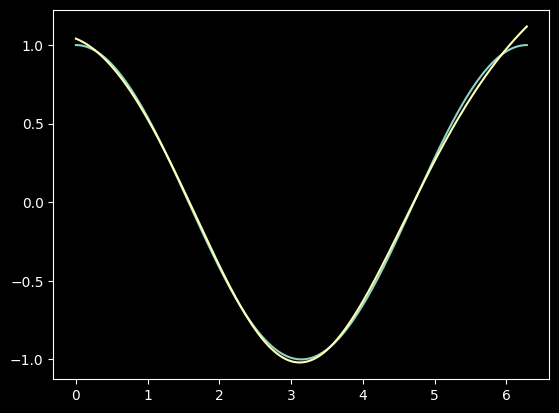

In [77]:
from matplotlib import pyplot as plt

plt.plot(x_sin, np.cos(x_sin), label="cos(x)",)
plt.plot(x_sin, net.forward(x_sin), label="predicted")

In [73]:
net.forward(x_sin)

array([[ 0.04015709],
       [ 0.04448976],
       [ 0.04886179],
       [ 0.05327279],
       [ 0.05772238],
       [ 0.06221014],
       [ 0.06673566],
       [ 0.07129852],
       [ 0.07589828],
       [ 0.08053451],
       [ 0.08520676],
       [ 0.08991457],
       [ 0.09465748],
       [ 0.09943502],
       [ 0.10424671],
       [ 0.10909206],
       [ 0.11397058],
       [ 0.11888177],
       [ 0.12382512],
       [ 0.12880011],
       [ 0.13380622],
       [ 0.13884292],
       [ 0.14390967],
       [ 0.14900593],
       [ 0.15413114],
       [ 0.15928476],
       [ 0.16446621],
       [ 0.16967494],
       [ 0.17491035],
       [ 0.18017188],
       [ 0.18545893],
       [ 0.19077092],
       [ 0.19610723],
       [ 0.20146729],
       [ 0.20685046],
       [ 0.21225614],
       [ 0.21768372],
       [ 0.22313256],
       [ 0.22860205],
       [ 0.23409155],
       [ 0.23960043],
       [ 0.24512804],
       [ 0.25067375],
       [ 0.2562369 ],
       [ 0.26181686],
       [ 0